## Project1: Centrality Measures


**Dataset:** SNAP/MUSAE GitHub Social Network  
**Source:** https://snap.stanford.edu/data/github-social.html  
**Citation:** Rozemberczki, Allen & Sarkar (2019), *Multi-scale Attributed Node Embedding*, arXiv:1909.13021

This project examines whether Web developers and ML developers differ in centrality within the GitHub mutual-follow network. Using degree and eigenvector centrality on 37,700 nodes, 
I find that Web developers are significantly more central on both measures, with a larger gap in eigenvector centrality, 
suggesting Web developers dominate both the popular and the influential positions in the network.


**Files used:**
- `musae_git_edges.csv` — edge list (`id_1`, `id_2`) → 289,003 mutual-follow edges
- `musae_git_target.csv` — node metadata (`id`, `name`, `ml_target`) → categorical label (0 = web developer, 1 = ML developer)
- `musae_git_features.json` — node features (not needed for centrality analysis, loaded for completeness)

**Goal of this notebook (proposal stage):** 

-   Load the raw files, build the graph, attach the categorical

-   Label to each node, and run a *quick* EDA 

-   Degree Centrality

-   Statistical analysis

-   Conclusions

-   References

### 1. Imports

In [29]:
import json
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy import stats # for statistical tests


### 2. Load the raw files

In [6]:
# Edge list: two columns, id_1 and id_2 (undirected mutual-follow relationship)
edges_df = pd.read_csv("git_web_ml/musae_git_edges.csv")

# Node target/category: id, username, ml_target (0 = web dev, 1 = ML dev)
target_df = pd.read_csv("git_web_ml/musae_git_target.csv")

# Node features: dict of {node_id: [list of feature ids]}
with open(f"git_web_ml/musae_git_features.json") as f:
    features_dict = json.load(f)

print("Edges shape:", edges_df.shape)
print("Target shape:", target_df.shape)
print("Number of nodes with features:", len(features_dict))
edges_df.head()


Edges shape: (289003, 2)
Target shape: (37700, 3)
Number of nodes with features: 37700


,id_1,id_2
0,0,23977
1,1,34526
2,1,2370
3,1,14683
4,1,29982


In [7]:
target_df.head()

,id,name,ml_target
0,0,Eiryyy,0
1,1,shawflying,0
2,2,JpMCarrilho,1
3,3,SuhwanCha,0
4,4,sunilangadi2,1


## 3. Build the graph and attach the categorical attribute

We build an undirected `networkx` graph from the edge list, then attach each node's
`ml_target` category (0 = web developer, 1 = ML developer) and username as node attributes,
so the label travels with the node for later centrality comparisons.


In [8]:
G = nx.from_pandas_edgelist(edges_df, source="id_1", target="id_2")

# Map id -> ml_target / name for quick lookup, then attach as node attributes
target_lookup = target_df.set_index("id")[["name", "ml_target"]].to_dict(orient="index")

nx.set_node_attributes(G, {n: v["name"] for n, v in target_lookup.items()}, name="name")
nx.set_node_attributes(G, {n: v["ml_target"] for n, v in target_lookup.items()}, name="ml_target")

print("Number of nodes in graph:", G.number_of_nodes())
print("Number of edges in graph:", G.number_of_edges())

# Sanity check on one node
sample_node = list(G.nodes)[0]
print("Sample node:", sample_node, G.nodes[sample_node])


Number of nodes in graph: 37700
Number of edges in graph: 289003
Sample node: 0 {'name': 'Eiryyy', 'ml_target': 0}


### 4. Exploratory Data Analysis  

ml_target
Web developer    27961
ML developer      9739
Name: count, dtype: int64


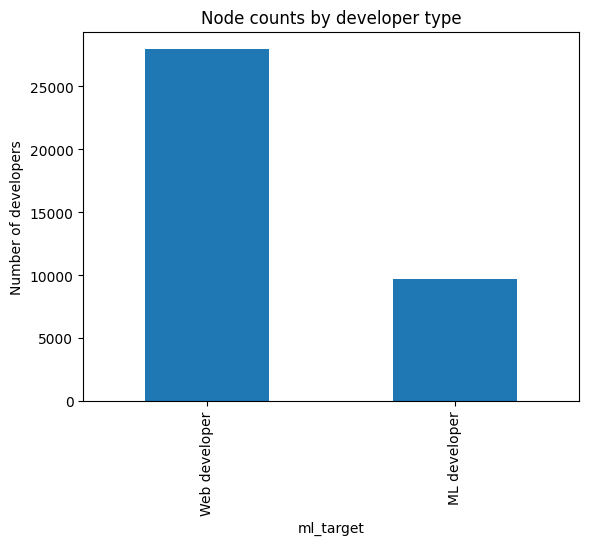

In [9]:
# Class balance of the categorical variable
label_map = {0: "Web developer", 1: "ML developer"}
class_counts = target_df["ml_target"].map(label_map).value_counts()
print(class_counts)

class_counts.plot(kind="bar", title="Node counts by developer type")
plt.ylabel("Number of developers")
plt.show()


Density: 0.0004066878203117068
count    37700.000000
mean        15.331724
std         80.788102
min          1.000000
25%          2.000000
50%          6.000000
75%         13.000000
max       9458.000000
Name: degree, dtype: float64


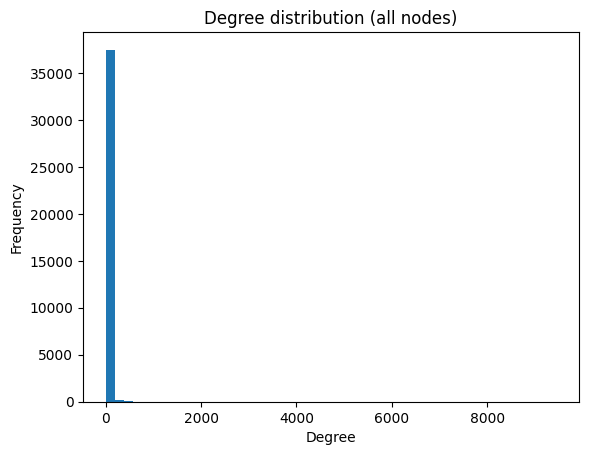

In [10]:
# Basic graph-level stats
print("Density:", nx.density(G))
degrees = dict(G.degree())
degree_series = pd.Series(degrees, name="degree")
print(degree_series.describe())

degree_series.plot(kind="hist", bins=50, title="Degree distribution (all nodes)")
plt.xlabel("Degree")
plt.show()


***NOTE***.    **Degree distribution is heavily skewed,** Stats shows it: std (80.8) is much larger than the mean (15.3), and max degree (9,458)

## 5. Quick peek at degree by category


In [11]:
# Attach degree back to a dataframe with the category label for a quick group comparison
degree_df = degree_series.reset_index().rename(columns={"index": "id"})
merged_df = degree_df.merge(target_df, on="id")
merged_df["ml_target_label"] = merged_df["ml_target"].map(label_map)

merged_df.groupby("ml_target_label")["degree"].describe()


,count,mean,std,min,25%,50%,75%,max
ml_target_label,,,,,,,,
ML developer,9739.0,8.631687,22.253630,1.0,2.0,4.0,9.0,967.0
Web developer,27961.0,17.665391,92.771422,1.0,3.0,6.0,15.0,9458.0


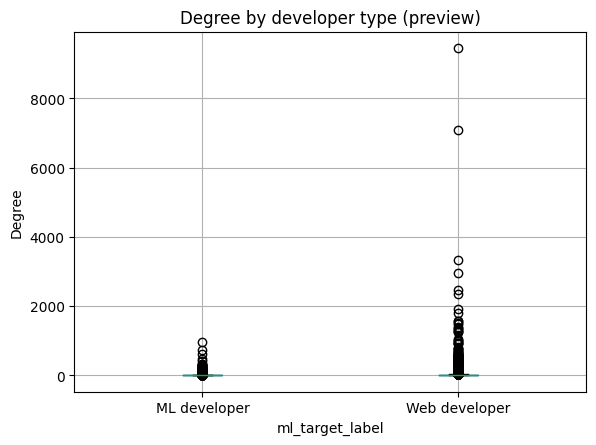

In [12]:
merged_df.boxplot(column="degree", by="ml_target_label")
plt.title("Degree by developer type (preview)")
plt.suptitle("")
plt.ylabel("Degree")
plt.show()


### Compute Degree Centrality  

In [13]:
# Step 1: Compute degree centrality for every node
degree_centrality = nx.degree_centrality(G)

# Quick sanity check
print("Number of nodes with degree centrality:", len(degree_centrality))
print("Sample values:")
for node in list(degree_centrality)[:5]:
    print(f"  Node {node}: {degree_centrality[node]:.6f}")

# Basic summary stats
dc_series = pd.Series(degree_centrality, name="degree_centrality")
print("\nSummary statistics:")
print(dc_series.describe())

Number of nodes with degree centrality: 37700
Sample values:
  Node 0: 0.000027
  Node 23977: 0.000849
  Node 1: 0.000212
  Node 34526: 0.000053
  Node 2370: 0.001061

Summary statistics:
count    37700.000000
mean         0.000407
std          0.002143
min          0.000027
25%          0.000053
50%          0.000159
75%          0.000345
max          0.250882
Name: degree_centrality, dtype: float64


**Interpretation**

-   Degree centrality is just a normalized version of degree, it lets you compare nodes across networks of different sizes. 

-   The degree centrality scores are extremely small (mean ≈ 0.0004, max ≈ 0.251), confirming that this is a sparse network where most developers follow only a tiny fraction of the other 37,699 nodes.

-   The distribution is heavily right-skewed, the median (0.00016) is well below the mean, and the max (0.251) is roughly 615× the mean, indicating a few highly connected hubs dominate the network.

-   This mirrors the skewed degree distribution observed in the earlier EDA and sets up an interesting comparison with eigenvector centrality in the next step.

### Compute Eigenvector Centrality

*Eigenvector centrality measures how connected a node is to other well-connected nodes.*

In [14]:
# Step 2: Compute eigenvector centrality for every node
# Increase max_iter because default 100 is too low for a graph this size
eigen_centrality = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-6)

# Sanity check
print("Number of nodes with eigenvector centrality:", len(eigen_centrality))
print("Sample values:")
for node in list(eigen_centrality)[:5]:
    print(f"  Node {node}: {eigen_centrality[node]:.6f}")

# Summary stats
ec_series = pd.Series(eigen_centrality, name="eigenvector_centrality")
print("\nSummary statistics:")
print(ec_series.describe())

Number of nodes with eigenvector centrality: 37700
Sample values:
  Node 0: 0.000047
  Node 23977: 0.006981
  Node 1: 0.000952
  Node 34526: 0.000364
  Node 2370: 0.007655

Summary statistics:
count    3.770000e+04
mean     2.372857e-03
std      4.571138e-03
min      3.543992e-12
25%      1.671725e-04
50%      1.083886e-03
75%      3.186910e-03
max      3.559490e-01
Name: eigenvector_centrality, dtype: float64


**Summary:**

-   Eigenvector centrality was successfully computed for all 37,700 nodes, with scores ranging from almost zero to a maximum of 0.356.

-   The scores are more spread out than degree centrality — a few highly influential nodes hold much larger scores than everyone else.

-   This confirms that influence in this network is concentrated in a small number of well-connected hubs, rather than spread evenly across developers.


### Combine centrality scores with the category label into one DataFrame

In [15]:
# Step 3: Combine centrality scores with the category label into one DataFrame

# Build a DataFrame from the two centrality dictionaries
centrality_df = pd.DataFrame({
    "id": list(degree_centrality.keys()),
    "degree_centrality": list(degree_centrality.values()),
    "eigenvector_centrality": list(eigen_centrality.values()),
})

# Merge in the category label and username from target_df
centrality_df = centrality_df.merge(target_df, on="id", how="left")

# Add human-readable label
centrality_df["ml_target_label"] = centrality_df["ml_target"].map(label_map)

# Preview
print("Shape:", centrality_df.shape)
print("\nFirst 5 rows:")
print(centrality_df.head())

print("\nMissing values per column:")
print(centrality_df.isna().sum())

Shape: (37700, 6)

First 5 rows:
      id  degree_centrality  eigenvector_centrality        name  ml_target  \
0      0           0.000027                0.000047      Eiryyy          0   
1  23977           0.000849                0.006981    airtoxin          0   
2      1           0.000212                0.000952  shawflying          0   
3  34526           0.000053                0.000364     ghosind          0   
4   2370           0.001061                0.007655     jasondu          0   

  ml_target_label  
0   Web developer  
1   Web developer  
2   Web developer  
3   Web developer  
4   Web developer  

Missing values per column:
id                        0
degree_centrality         0
eigenvector_centrality    0
name                      0
ml_target                 0
ml_target_label           0
dtype: int64


### Top 5 Nodes

In [16]:
# Top 5 nodes by degree centrality
print("Top 5 by degree centrality:")
print(centrality_df.nlargest(5, "degree_centrality")[["id", "name", "ml_target_label", "degree_centrality"]])

print("\nTop 5 by eigenvector centrality:")
print(centrality_df.nlargest(5, "eigenvector_centrality")[["id", "name", "ml_target_label", "eigenvector_centrality"]])

Top 5 by degree centrality:
        id               name ml_target_label  degree_centrality
28   31890       dalinhuang99   Web developer           0.250882
24   27803             nfultz   Web developer           0.187936
35   35773         addyosmani   Web developer           0.088172
82   19222            Bunlong   Web developer           0.078464
109  13638  gabrielpconceicao   Web developer           0.065466

Top 5 by eigenvector centrality:
        id               name ml_target_label  eigenvector_centrality
28   31890       dalinhuang99   Web developer                0.355949
24   27803             nfultz   Web developer                0.301655
35   35773         addyosmani   Web developer                0.161677
82   19222            Bunlong   Web developer                0.148842
109  13638  gabrielpconceicao   Web developer                0.119461


**Summary:**

-   The combined DataFrame has 37,700 rows and 6 columns, with no missing values, every node has a category label and both centrality scores.

-   The top 5 nodes by both degree and eigenvector centrality are identical, and all five are Web developers (e.g., dalinhuang99, nfultz, addyosmani).

-   This is an early hint that Web developers may dominate the high-centrality end of the network, which is exactly what we'll test formally in Steps 4 and 5.

### Group-Level Summary Statistics and Visualizations

In [17]:
# Step 4a: Group-level summary statistics
summary = centrality_df.groupby("ml_target_label")[
    ["degree_centrality", "eigenvector_centrality"]
].describe().T

print("Group-level summary statistics:")
print(summary)

Group-level summary statistics:
ml_target_label               ML developer  Web developer
degree_centrality      count  9.739000e+03   2.796100e+04
                       mean   2.289633e-04   4.685904e-04
                       std    5.902976e-04   2.460846e-03
                       min    2.652590e-05   2.652590e-05
                       25%    5.305181e-05   7.957771e-05
                       50%    1.061036e-04   1.591554e-04
                       75%    2.387331e-04   3.978885e-04
                       max    2.565055e-02   2.508820e-01
eigenvector_centrality count  9.739000e+03   2.796100e+04
                       mean   1.148229e-03   2.799403e-03
                       std    1.815947e-03   5.130369e-03
                       min    3.543992e-12   6.515396e-12
                       25%    5.741471e-05   3.091169e-04
                       50%    2.855791e-04   1.646915e-03
                       75%    2.138083e-03   3.686916e-03
                       max    5.316942e-

**Overall takeaway**

-   On both centrality measures, Web developers appear to be significantly more central than ML developers.

-   The gap is larger for eigenvector centrality than for degree centrality, which suggests Web developers aren't just more connected, they're connected to other well-connected nodes.

#### Box Plot

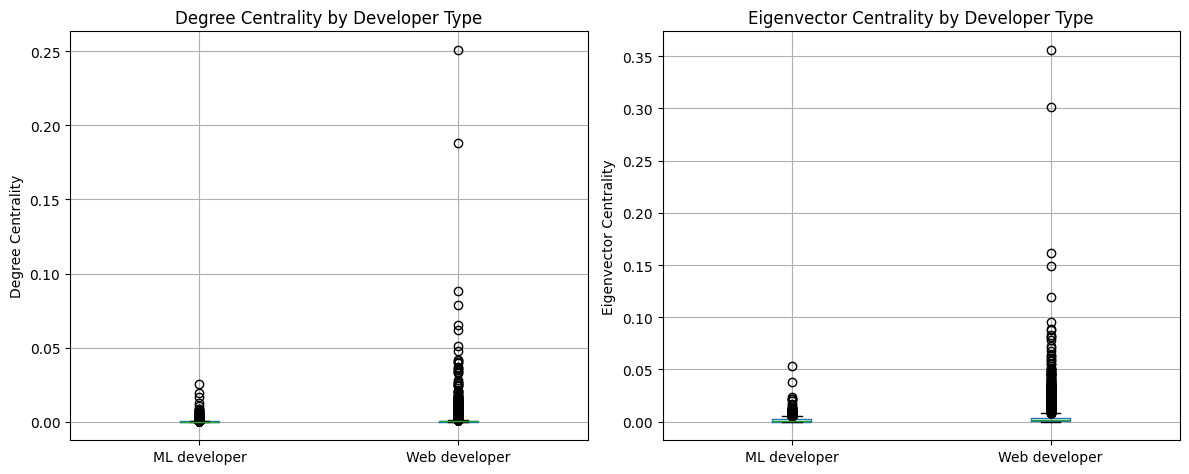

In [18]:
# Step 4b: Box plots comparing the two groups
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

centrality_df.boxplot(column="degree_centrality", by="ml_target_label", ax=axes[0])
axes[0].set_title("Degree Centrality by Developer Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Degree Centrality")

centrality_df.boxplot(column="eigenvector_centrality", by="ml_target_label", ax=axes[1])
axes[1].set_title("Eigenvector Centrality by Developer Type")
axes[1].set_xlabel("")
axes[1].set_ylabel("Eigenvector Centrality")

plt.suptitle("")   # remove default pandas title
plt.tight_layout()
plt.show()

 **Summary — Box Plots**

**Degree Centrality:** Web developers have a visibly higher median (green line) and a much longer tail of outliers reaching up to ~0.25, while ML developers' outliers top out around ~0.03, a nearly 10× difference in the extreme upper range.

**Eigenvector Centrality:** The contrast is even sharper: Web developers show outliers climbing past 0.35, whereas ML developers' highest outlier is only ~0.05, a ~7× gap.

**Both plots confirm the summary statistics:** Web developers are more central on average, and the network's most extreme hubs are almost exclusively Web developers.
The extremely dense bottom cluster in both plots reflects how sparse and skewed the graph is, most nodes sit near zero regardless of group

#### 4c. Histograms — distribution shapes

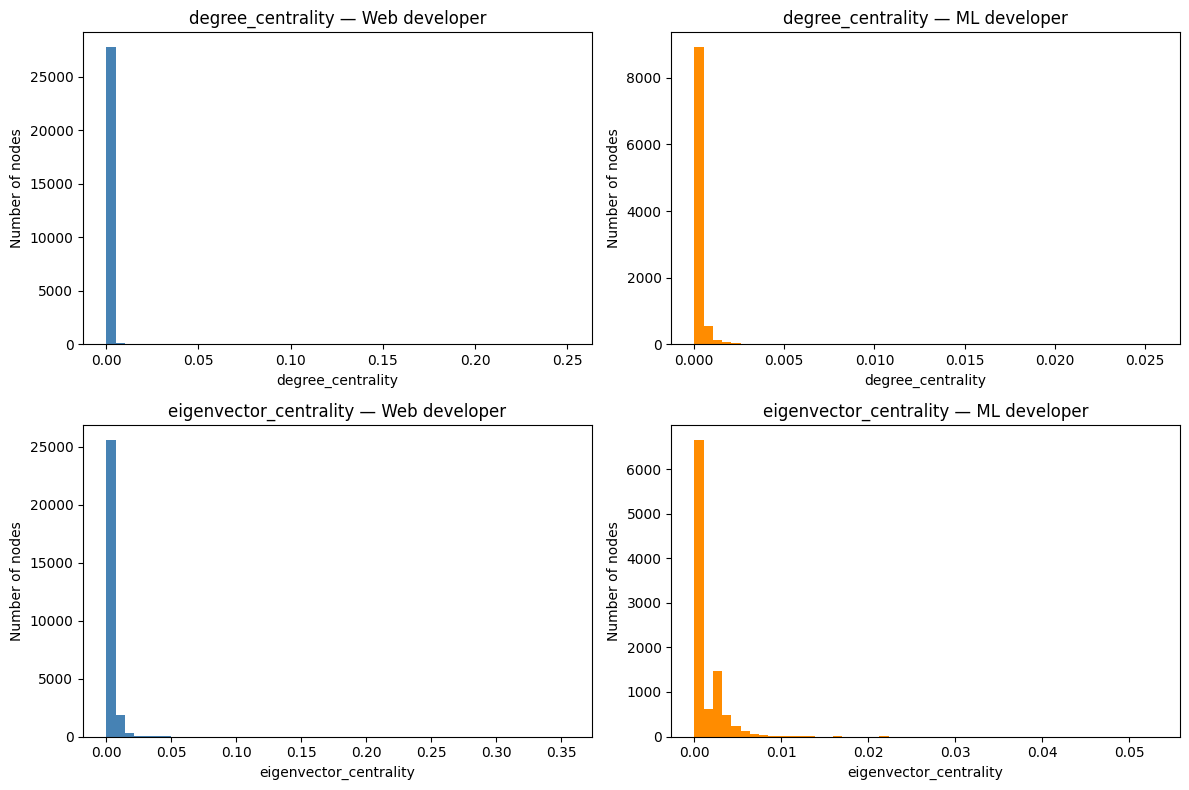

In [19]:
# Step 4c: Histograms of each centrality measure by group
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, measure in enumerate(["degree_centrality", "eigenvector_centrality"]):
    for j, group in enumerate(["Web developer", "ML developer"]):
        subset = centrality_df[centrality_df["ml_target_label"] == group][measure]
        axes[i, j].hist(subset, bins=50, color="steelblue" if j == 0 else "darkorange")
        axes[i, j].set_title(f"{measure} — {group}")
        axes[i, j].set_xlabel(measure)
        axes[i, j].set_ylabel("Number of nodes")

plt.tight_layout()
plt.show()

**Linear histograms:** Both groups are compressed into a single spike near zero, the skew is so extreme that the linear view hides all the interesting structure beyond the first bin.

#### Log-scale histograms

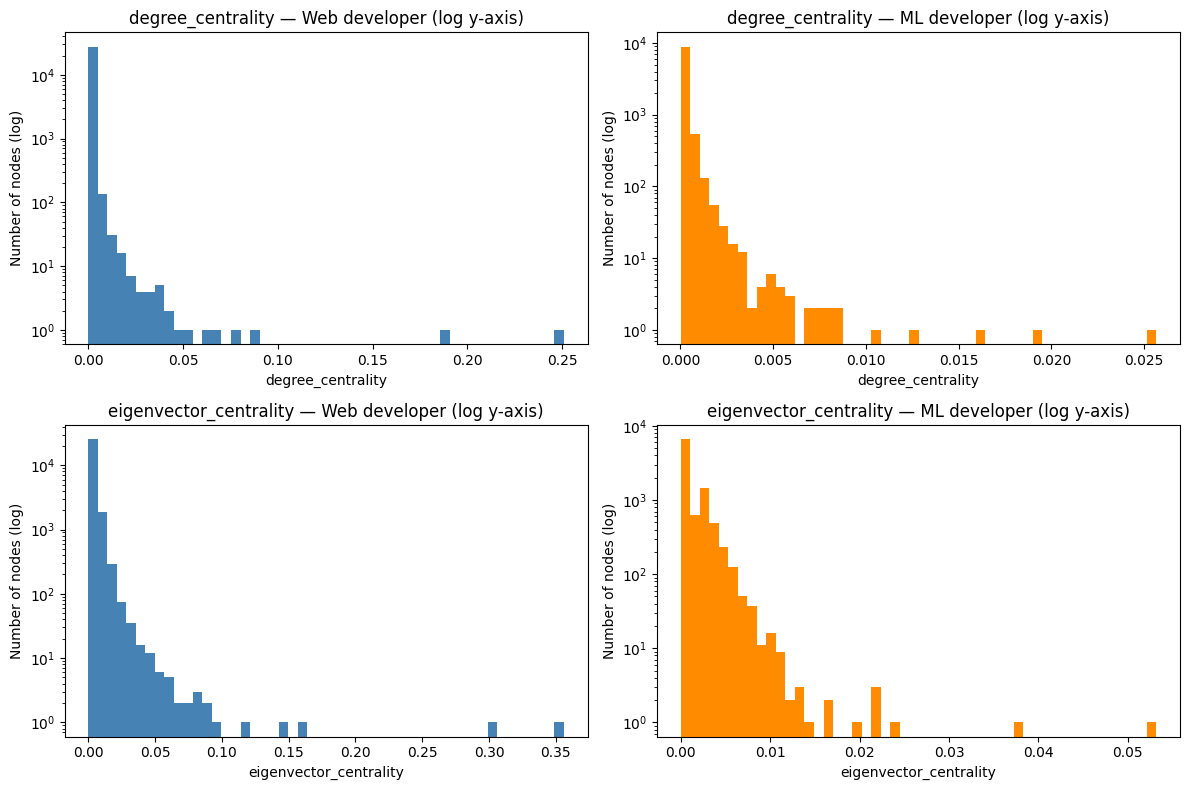

In [21]:
# Step 4d: Log-scale histograms for better visibility
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, measure in enumerate(["degree_centrality", "eigenvector_centrality"]):
    for j, group in enumerate(["Web developer", "ML developer"]):
        subset = centrality_df[centrality_df["ml_target_label"] == group][measure]
        axes[i, j].hist(subset, bins=50, color="steelblue" if j == 0 else "darkorange")
        axes[i, j].set_yscale("log")
        axes[i, j].set_title(f"{measure} — {group} (log y-axis)")
        axes[i, j].set_xlabel(measure)
        axes[i, j].set_ylabel("Number of nodes (log)")

plt.tight_layout()
plt.show()

**4 Log-scale histograms Summary**

-   The long tails become visible.

-   Web developers (blue) extend far to the right — reaching ~0.25 for degree centrality and ~0.35 for eigenvector centrality.

-   ML developers (orange) drop off much sooner — their tails end around 0.026 for degree and 0.053 for eigenvector.

-   The right tail is roughly 10× longer for Web developers on degree centrality and ~7× longer on eigenvector centrality, matching what we saw in the box plots.

-   This visual evidence strongly suggests the two groups differ in centrality but we still need Step 5 to confirm the difference is statistically significant.

#### Statistical Testing

Why two tests?

**Welch's t-test** — compares the means of the two groups. It does not assume equal variances (unlike Student's t-test), which is important here because the Web developer group has a much larger variance.

**Mann-Whitney U test** — a non-parametric alternative that compares the distributions rather than the means. It does not assume normality, which matters because both centrality measures are extremely right-skewed (as the histograms showed)


In [ ]:
# Step 5a: Statistical tests comparing Web vs. ML developers


# Split into two groups
web = centrality_df[centrality_df["ml_target_label"] == "Web developer"]
ml  = centrality_df[centrality_df["ml_target_label"] == "ML developer"]

def cohens_d(x, y):
    """Compute Cohen's d for two independent samples."""
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx - 1) * x.std(ddof=1)**2 + (ny - 1) * y.std(ddof=1)**2) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_std

for measure in ["degree_centrality", "eigenvector_centrality"]:
    x = web[measure]
    y = ml[measure]

    # Welch's t-test (equal_var=False)
    t_stat, t_p = stats.ttest_ind(x, y, equal_var=False)

    # Mann-Whitney U test
    u_stat, u_p = stats.mannwhitneyu(x, y, alternative="two-sided")

    # Cohen's d
    d = cohens_d(x, y)

    print(f"=== {measure} ===")
    print(f"  Web mean:  {x.mean():.6f}")
    print(f"  ML  mean:  {y.mean():.6f}")
    print(f"  Welch's t-test:    t = {t_stat:.3f}, p = {t_p:.3e}")
    print(f"  Mann-Whitney U:    U = {u_stat:.1f}, p = {u_p:.3e}")
    print(f"  Cohen's d:         {d:.3f}")
    print()

=== degree_centrality ===
  Web mean:  0.000469
  ML  mean:  0.000229
  Welch's t-test:    t = 15.084, p = 2.968e-51
  Mann-Whitney U:    U = 166877674.5, p = 2.062e-243
  Cohen's d:         0.112

=== eigenvector_centrality ===
  Web mean:  0.002799
  ML  mean:  0.001148
  Welch's t-test:    t = 46.153, p = 0.000e+00
  Mann-Whitney U:    U = 185775200.5, p = 0.000e+00
  Cohen's d:         0.366



#### Degree Centrality


-   Web developers have a mean of 0.000469 vs. ML developers' 0.000229 — roughly 2× higher.

-   Welch's t-test: t = 15.08, p ≈ 3 × 10⁻⁵¹ → the difference is highly significant.

-   Mann-Whitney U: p ≈ 2 × 10⁻²⁴³ → also highly significant (non-parametric confirmation).

-   Cohen's d = 0.112 → a small effect size.

#### Eigenvector Centrality


-   Web mean = 0.002799 vs. ML mean = 0.001148 — roughly 2.4× higher.

-   Welch's t-test: t = 46.15, p ≈ 0 → even stronger evidence than for degree centrality.

-   Mann-Whitney U: p ≈ 0 → same conclusion.

-   Cohen's d = 0.366 → a small-to-medium effect size, roughly 3× larger than the degree centrality effect.

**Overall Takeaways**


-   Both centrality measures differ significantly between Web and ML developers — all four tests reject the null hypothesis with astronomically small p-values.

-   However, effect sizes are modest (0.11 and 0.37). With 37,700 nodes, even tiny differences become "significant," so the p-values alone overstate the practical importance.

-   The eigenvector centrality gap is more meaningful than the degree centrality gap — Web developers aren't just more connected, they're notably more connected to other well-connected nodes.

-   This supports the hypothesis from the proposal: Web developers dominate the network's central hubs, and the influence gap is larger than the popularity gap.

#### BFS Neighborhood of the Top Hub (depth 2, ~500 nodes)

BFS sample: 500 nodes, 754 edges


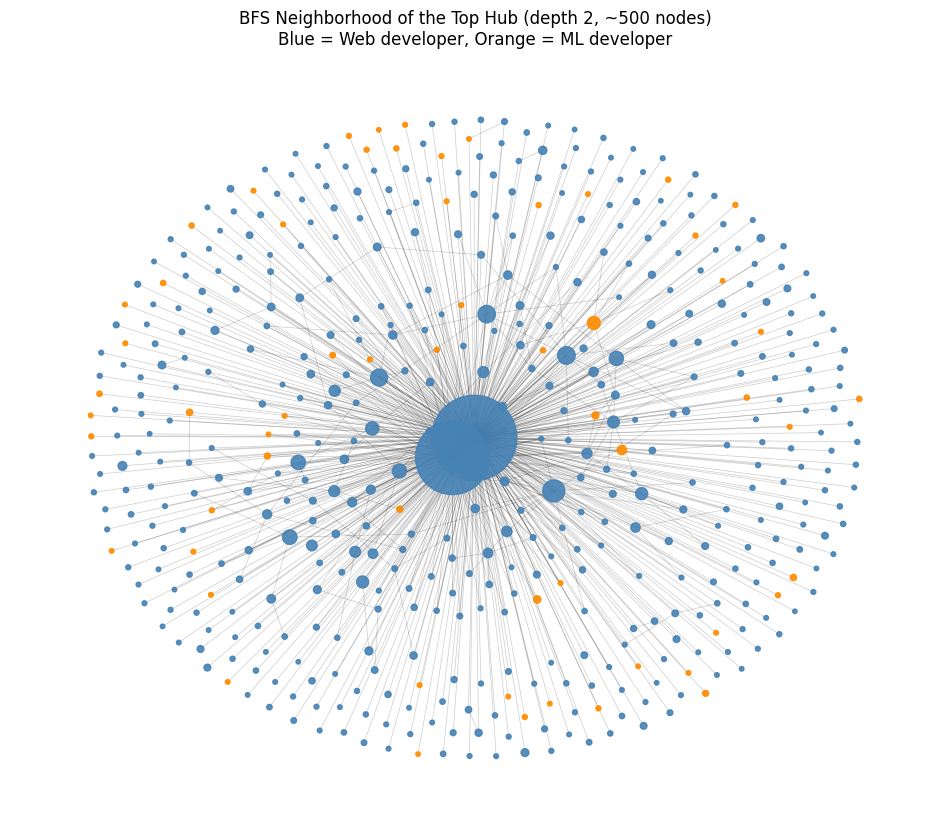

In [28]:
# BFS-based sample centered on the top hub — keeps the sample connected
start = max(degree_centrality, key=degree_centrality.get)
bfs_nodes = list(nx.bfs_tree(G, start, depth_limit=2).nodes)[:500]
H = G.subgraph(bfs_nodes).copy()

print(f"BFS sample: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")

color_map = {0: "steelblue", 1: "darkorange"}
node_colors = [color_map[H.nodes[n]["ml_target"]] for n in H.nodes]
sizes = [degree_centrality[n] * 15000 + 10 for n in H.nodes]

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(H, seed=42, k=0.3)
nx.draw_networkx_edges(H, pos, alpha=0.2, width=0.5)
nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=sizes, alpha=0.9)
plt.title("BFS Neighborhood of the Top Hub (depth 2, ~500 nodes)\nBlue = Web developer, Orange = ML developer")
plt.axis("off")
plt.show()

**BFS Neighborhood of the Top Hub (depth 2, ~500 nodes)**

-   The plot shows the top hub (dalinhuang99) and its 2-hop neighborhood, sampled via BFS so that every node is genuinely connected to the hub.

-   The dense blue core in the center represents the hub and its immediate Web-developer peers — these nodes have the largest sizes because they have the highest degree centrality.

-   ML developers (orange) appear only at the outer ring — they are reachable within 2 hops but do not belong to the hub's inner community.

-   This provides a local, structural confirmation of the global pattern: the network's central hub is embedded in a Web-developer cluster, and ML developers sit at the periphery even when the hub is at the center.


#### Top-30 Hubs and Their Top-20 Neighbors

Hub subgraph: 106 nodes, 1474 edges


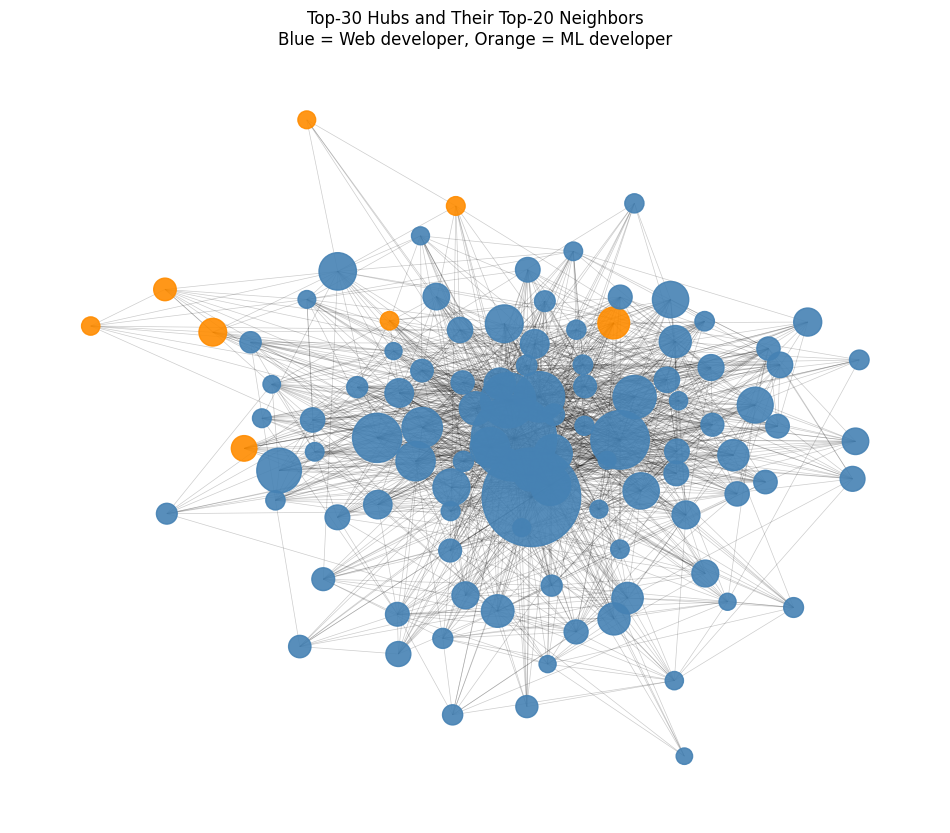

In [25]:
# Top 30 hubs by degree centrality
top_nodes = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:30]

# For each hub, keep only its top 20 highest-degree neighbors
neighbors = set()
for n in top_nodes:
    nbrs = sorted(G.neighbors(n), key=lambda x: degree_centrality[x], reverse=True)[:20]
    neighbors.update(nbrs)

sub_nodes = list(set(top_nodes) | neighbors)
H2 = G.subgraph(sub_nodes).copy()
print(f"Hub subgraph: {H2.number_of_nodes()} nodes, {H2.number_of_edges()} edges")

color_map = {0: "steelblue", 1: "darkorange"}
node_colors = [color_map[H2.nodes[n]["ml_target"]] for n in H2.nodes]
sizes = [degree_centrality[n] * 20000 + 10 for n in H2.nodes]

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(H2, seed=42, k=0.3)
nx.draw_networkx_edges(H2, pos, alpha=0.2, width=0.5)
nx.draw_networkx_nodes(H2, pos, node_color=node_colors, node_size=sizes, alpha=0.9)
plt.title("Top-30 Hubs and Their Top-20 Neighbors\nBlue = Web developer, Orange = ML developer")
plt.axis("off")
plt.show()

**Top-30 Hubs and Their Top-20 Neighbors**

-   The largest blue nodes at the center are the network's top Web-developer hubs; they are connected to nearly every other node in the plot.

-   Orange (ML developer) nodes are pushed to the periphery, they appear only as small satellites attached to a small number of hubs.

-   The plot provides a structural confirmation of the early findings: the network's central backbone is dominated by Web developers, and ML developers do not occupy the innermost core.

#### Log-log Degree Distribution

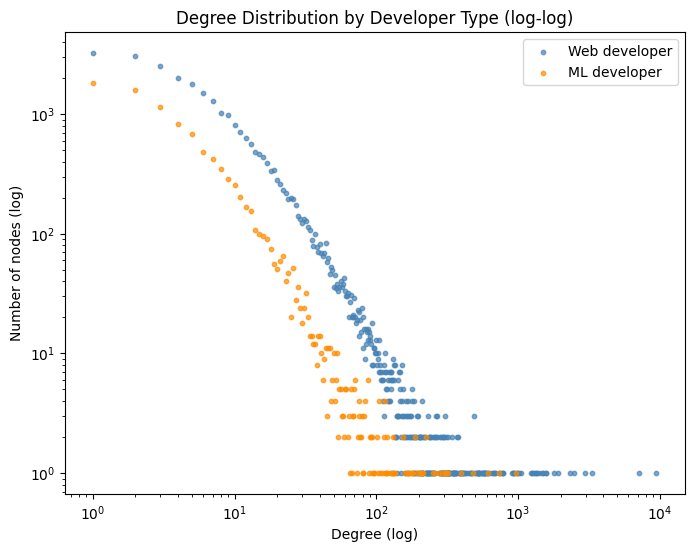

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))

for group, color in [("Web developer", "steelblue"), ("ML developer", "darkorange")]:
    degrees = [d for n, d in G.degree() if G.nodes[n]["ml_target"] == (0 if group == "Web developer" else 1)]
    counts = pd.Series(degrees).value_counts().sort_index()
    ax.scatter(counts.index, counts.values, s=10, color=color, label=group, alpha=0.7)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Degree (log)")
ax.set_ylabel("Number of nodes (log)")
ax.set_title("Degree Distribution by Developer Type (log-log)")
ax.legend()
plt.show()

**Degree Distribution by Developer Type (log-log)**

-   Both groups follow a power-law-like distribution: a straight-line tail on log-log axes, meaning a small number of nodes have very high degree.

-   The Web developer tail extends roughly 10× further — reaching degree ~9,458, versus ~967 for ML developers.

-   At every degree level above ~10, Web developers outnumber ML developers, but the ratio is especially pronounced at the tail, confirming that the network's largest hubs are almost exclusively Web developers.

###    Conclusion 

-   Both degree centrality and eigenvector centrality differ significantly between Web and ML developers in the GitHub mutual-follow network. 

-   Web developers occupy both the most popular and the most influential positions, with the eigenvector centrality gap (Cohen's d = 0.37) roughly three times larger than the degree centrality gap (d = 0.11). 

-   While the p-values are astronomically small, the modest effect sizes indicate that the difference is driven by a small number of highly central hubs rather than a broad shift across the entire group. 

*These findings support the prediction that centrality measures can serve as weak signals for a developer's domain, and suggest that the Web development community on GitHub is more broadly interconnected, while the ML community forms smaller, tighter clusters that do not intersect with the network's global hubs.*

#### References 

Rozemberczki, B., Allen, C., & Sarkar, R. (2019). Multi-scale Attributed Node Embedding. arXiv:1909.13021.
 
SNAP/MUSAE GitHub Social Network: https://snap.stanford.edu/data/github-social.html 